$y=\sin(x)e^{-0.5x}$

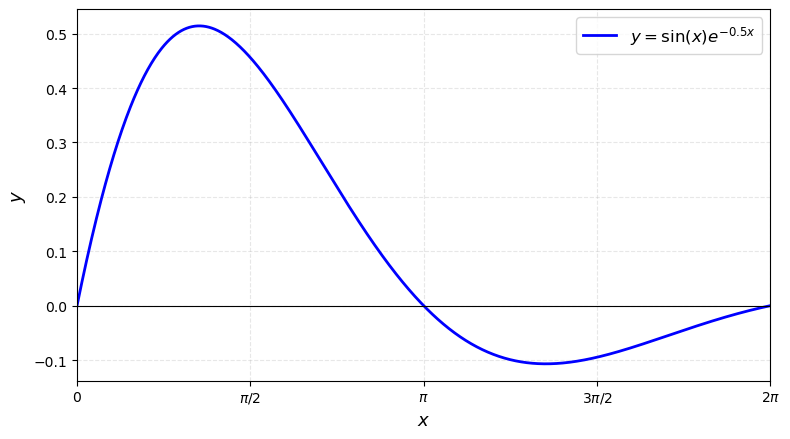

In [60]:
import numpy as np
import matplotlib.pyplot as plt

# 定义函数
x = np.linspace(0, 2 * np.pi, 1000)
y = np.sin(x) * np.exp(-0.5 * x)

# 绘图
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, y, color="blue", linewidth=2, label=r"$y=\sin(x)e^{-0.5x}$")

# 坐标轴
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlim(0, 2 * np.pi)
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$y$", fontsize=13)
ax.set_xticks(np.linspace(0, 2 * np.pi, 5))
ax.set_xticklabels([r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"])

# 图例与网格
ax.legend(fontsize=12)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

训练集: torch.Size([160, 1]) torch.Size([160, 1])
测试集: torch.Size([40, 1]) torch.Size([40, 1])


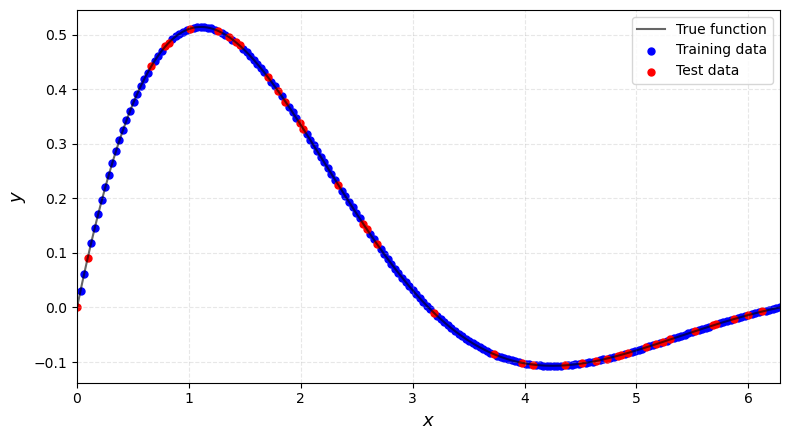

In [61]:
import torch

# 1. 生成100个数据点
x_data = torch.linspace(0, 2 * torch.pi, 200).reshape(-1, 1)
y_data = torch.sin(x_data) * torch.exp(-0.5 * x_data)

# 2. 输入归一化到 [-1, 1]
X = x_data / torch.pi - 1
Y = y_data.clone()

# 3. 随机划分训练集和测试集（80:20）
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(len(X), generator=generator)
n_train = int(0.8 * len(X))

train_idx = indices[:n_train]
test_idx = indices[n_train:]

X_train, Y_train = X[train_idx], Y[train_idx]
X_test, Y_test = X[test_idx], Y[test_idx]

print("训练集:", X_train.shape, Y_train.shape)
print("测试集:", X_test.shape, Y_test.shape)

# 4. 绘制数据分布
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x, y, color="black", linewidth=1.5, alpha=0.6, label="True function")
ax.scatter(x_data[train_idx].numpy(), Y_train.numpy(), color="blue", s=25, label="Training data")
ax.scatter(x_data[test_idx].numpy(), Y_test.numpy(), color="red", s=25, label="Test data")

ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$y$", fontsize=13)
ax.set_xlim(0, 2 * np.pi)
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

In [62]:
import torch
import torch.nn as nn

# 定义 1-2-16-1 MLP
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 2),
            nn.Tanh(),
            nn.Linear(2, 8),
            nn.Tanh(),
            nn.Linear(8,8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )

    def forward(self, x):
        return self.network(x)

# 初始化模型
torch.manual_seed(42)
model = MLP()

print(model)

MLP(
  (network): Sequential(
    (0): Linear(in_features=1, out_features=2, bias=True)
    (1): Tanh()
    (2): Linear(in_features=2, out_features=8, bias=True)
    (3): Tanh()
    (4): Linear(in_features=8, out_features=8, bias=True)
    (5): Tanh()
    (6): Linear(in_features=8, out_features=1, bias=True)
  )
)


Epoch [500/8000] | Train Loss: 0.01145411 | Test Loss: 0.01449609
Epoch [1000/8000] | Train Loss: 0.00161097 | Test Loss: 0.00269646
Epoch [1500/8000] | Train Loss: 0.00049970 | Test Loss: 0.00081638
Epoch [2000/8000] | Train Loss: 0.00012282 | Test Loss: 0.00021679
Epoch [2500/8000] | Train Loss: 0.00002789 | Test Loss: 0.00005396
Epoch [3000/8000] | Train Loss: 0.00001136 | Test Loss: 0.00002036
Epoch [3500/8000] | Train Loss: 0.00000718 | Test Loss: 0.00001155
Epoch [4000/8000] | Train Loss: 0.00000469 | Test Loss: 0.00000711
Epoch [4500/8000] | Train Loss: 0.00000314 | Test Loss: 0.00000444
Epoch [5000/8000] | Train Loss: 0.00000229 | Test Loss: 0.00000293
Epoch [5500/8000] | Train Loss: 0.00000186 | Test Loss: 0.00000219
Epoch [6000/8000] | Train Loss: 0.00000369 | Test Loss: 0.00000411
Epoch [6500/8000] | Train Loss: 0.00000152 | Test Loss: 0.00000167
Epoch [7000/8000] | Train Loss: 0.00000143 | Test Loss: 0.00000159
Epoch [7500/8000] | Train Loss: 0.00000135 | Test Loss: 0.00000

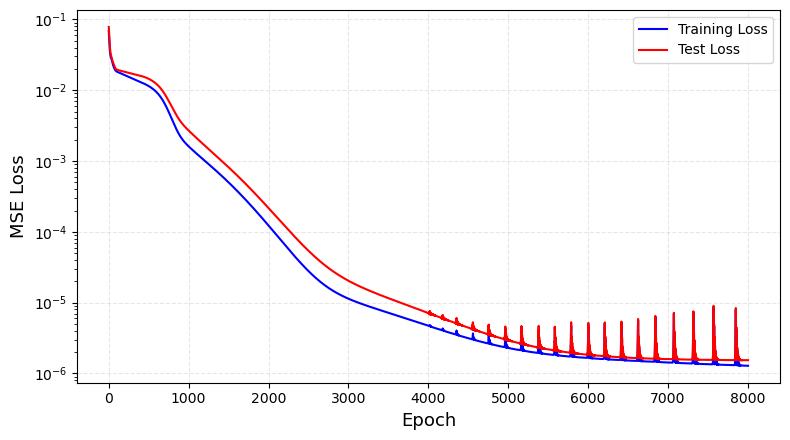

In [63]:
import torch.optim as optim

# 1. 定义损失函数和优化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. 设置训练参数
epochs = 8000
train_loss_history = []
test_loss_history = []

# 3. 训练模型
for epoch in range(epochs):
    model.train()

    # 前向传播
    y_pred = model(X_train)
    loss = criterion(y_pred, Y_train)

    # 反向传播
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 计算训练集与测试集 Loss
    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_train), Y_train).item()
        test_loss = criterion(model(X_test), Y_test).item()

    train_loss_history.append(train_loss)
    test_loss_history.append(test_loss)

    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.8f} | Test Loss: {test_loss:.8f}")

# 4. 绘制损失函数
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(range(1, epochs + 1), train_loss_history, color="blue", linewidth=1.5, label="Training Loss")
ax.plot(range(1, epochs + 1), test_loss_history, color="red", linewidth=1.5, label="Test Loss")

ax.set_xlabel("Epoch", fontsize=13)
ax.set_ylabel("MSE Loss", fontsize=13)
ax.set_yscale("log")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

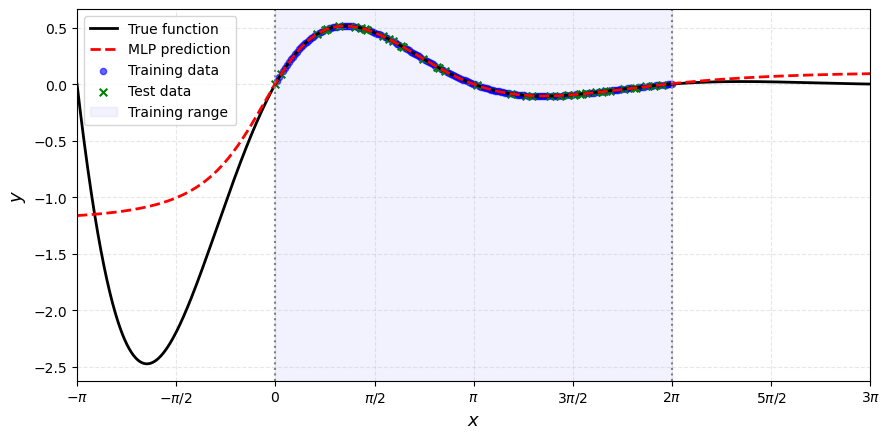

         x            True      Prediction       Abs Error
------------------------------------------------------------
   -3.1416        0.000000       -1.162958        1.162959
   -1.7460       -2.357453       -1.041803        1.315650
   -0.3505       -0.409088       -0.331612        0.077477
    1.0451        0.512936        0.512396        0.000540
    2.4407        0.190338        0.190995        0.000657
    3.8362       -0.094021       -0.093273        0.000749
    5.2318       -0.063461       -0.064867        0.001407
    6.6274        0.012276        0.022121        0.009845
    8.0229        0.017849        0.071219        0.053370
    9.4248       -0.000000        0.091747        0.091747

不同区间的拟合误差:
Interpolation [0, 2π]        MSE = 0.00000125, MAE = 0.00096694
Extrapolation [-π, 0)        MSE = 0.74241459, MAE = 0.71620888
Extrapolation (2π, 3π]       MSE = 0.00302715, MAE = 0.04744142


In [64]:
# 1. 生成2000个点，范围从 -π 到 3π
x_plot = torch.linspace(-torch.pi, 3 * torch.pi, 2000).reshape(-1, 1)
y_true = torch.sin(x_plot) * torch.exp(-0.5 * x_plot)

# 2. 使用训练好的MLP预测
model.eval()
with torch.no_grad():
    X_plot = x_plot / torch.pi - 1
    y_pred = model(X_plot)

# 3. 绘制真实函数与MLP预测曲线
fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(x_plot.numpy(), y_true.numpy(), color="black", linewidth=2, label="True function")
ax.plot(x_plot.numpy(), y_pred.numpy(), color="red", linewidth=2, linestyle="--", label="MLP prediction")

# 训练集与测试集
ax.scatter(x_data[train_idx].numpy(), Y_train.numpy(), color="blue", s=20, alpha=0.6, label="Training data")
ax.scatter(x_data[test_idx].numpy(), Y_test.numpy(), color="green", s=30, marker="x", label="Test data")

# 标记训练范围
ax.axvline(0, color="gray", linestyle=":", linewidth=1.5)
ax.axvline(2 * np.pi, color="gray", linestyle=":", linewidth=1.5)
ax.axvspan(0, 2 * np.pi, color="blue", alpha=0.05, label="Training range")

# 4. 坐标轴与图例
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$y$", fontsize=13)
ax.set_xlim(-np.pi, 3 * np.pi)
ax.set_xticks(np.linspace(-np.pi, 3 * np.pi, 9))
ax.set_xticklabels([
    r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$",
    r"$\pi$", r"$3\pi/2$", r"$2\pi$", r"$5\pi/2$", r"$3\pi$"
])

ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# 5. 打印10个点的真实值、预测值及绝对误差
indices = torch.linspace(0, len(x_plot) - 1, 10).long()

print(f"{'x':>10} {'True':>15} {'Prediction':>15} {'Abs Error':>15}")
print("-" * 60)

for i in indices:
    xv = x_plot[i].item()
    yt = y_true[i].item()
    yp = y_pred[i].item()
    print(f"{xv:10.4f} {yt:15.6f} {yp:15.6f} {abs(yt-yp):15.6f}")

# 6. 分别计算训练范围内和外推区域的误差
mask_inside = (x_plot[:, 0] >= 0) & (x_plot[:, 0] <= 2 * torch.pi)
mask_left = x_plot[:, 0] < 0
mask_right = x_plot[:, 0] > 2 * torch.pi

print("\n不同区间的拟合误差:")
for name, mask in [
    ("Interpolation [0, 2π]", mask_inside),
    ("Extrapolation [-π, 0)", mask_left),
    ("Extrapolation (2π, 3π]", mask_right)
]:
    mse = torch.mean((y_pred[mask] - y_true[mask])**2).item()
    mae = torch.mean(torch.abs(y_pred[mask] - y_true[mask])).item()
    print(f"{name:28s} MSE = {mse:.8f}, MAE = {mae:.8f}")